# 00 — Getting Started 

**zbi** es un pipeline de SBI (Simulation-Based Inference) que entrena MAFs (Masked Autoregressive Flows) con truncamiento secuencial del prior (tSNPE). Está construido sobre PyTorch y nflows. Los datos se guardan en disco con Zarr y los experimentos son reproducibles.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import zbi

%matplotlib inline

Sea un detector que mide una señal en 100 puntos equiespaciados entre -5 y 5. La señal es una recta con pendiente a e intercepto b, más ruido Gaussiano homogeneo. Es decir: $x_i = a \cdot g_i + b + \epsilon_i$ donde $\epsilon_i \sim \mathcal{N}(0, 0.1)$ y $g_i$ son los 100 puntos de la grilla. El problema inverso consiste en que dado un vector observado $x_o$, recuperar la distribución de los parámetros $(a, b)$ que lo generaron. SBI entrena un modelo generativo condicional como MAF que, dado $x_o$, produce muestras de $p(\theta \mid x_o)$.

Vamos a definir el simulador como una clase que hereda de `zbi.Simulator`. Esta clase debe implementar el método `simulate` que recibe un vector theta y devuelve un vector de señal x.

In [2]:
class SimuladorLineal(zbi.Simulator):
    def __init__(self):
        super().__init__()
        self.x_grid = torch.linspace(-5, 5, 100)

    def simulate(self, theta: torch.Tensor, seed: int | None = None) -> torch.Tensor:
        if seed is not None:
            torch.manual_seed(seed)
        a, b = theta[0].item(), theta[1].item()
        y = a * self.x_grid + b + 0.1 * torch.randn(100)
        return y

simulador = SimuladorLineal()

El MAF necesita recibir el dato $x$ en un espacio de dimensión fija y manejable. Nuestro $x$ tiene 100 dimensiones. Podríamos pasarlo directamente, pero es más eficiente proyectarlo a un espacio de menor dimensión con una red neuronal simple. A esto se le llama **embedding net**. En este caso usamos una sola capa lineal que proyecta de 100 a 5 dimensiones.

In [3]:
class EmbeddingNet(nn.Module):
    def __init__(self, dim_in: int = 100, dim_out: int = 5):
        super().__init__()
        self.net = nn.Linear(dim_in, dim_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

El prior sobre los parámetros es Uniforme en $[-3, 3]$ para ambos. El valor verdadero (desconocido para el algoritmo) es $\theta_{\text{true}} = (1.0, 0.5)$. Usamos `zbi.simulate_obs` para generar $x_o$ desde el simulador con los parámetros verdaderos. A continuación visualizamos el dato generado.

Dato observado x_o, shape: torch.Size([1, 100])


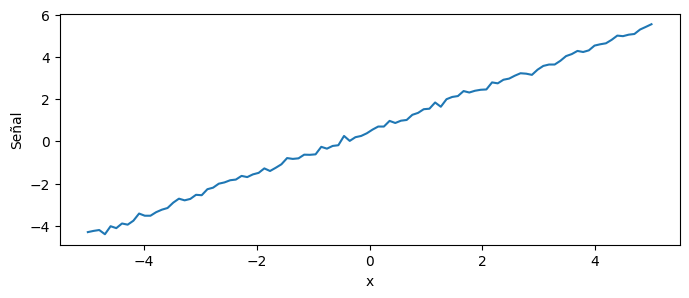

In [4]:
x_o = zbi.simulate_obs(simulador, theta_true=(1.0, 0.5), seed=42)
print(f"Dato observado x_o, shape: {x_o.shape}")

plt.figure(figsize=(8, 3))
plt.plot(simulador.x_grid.numpy(), x_o[0].numpy(), color="C0", lw=1.5)
plt.xlabel("x")
plt.ylabel("Señal")
plt.show()

`zbi.init` escribe `config.json`, inicializa el ZarrStore y guarda $x_o$ en disco. Si `config.json` ya existe, no hace nada.

In [5]:
zbi.init(
    run_dir="runs/tutorial_00", x_o=x_o,
    simulator_class=SimuladorLineal,
    embedding_class=EmbeddingNet,
    embedding_kwargs=dict(dim_in=100, dim_out=5),
    prior_low=(-3.0, -3.0), prior_high=(3.0, 3.0),
    dim_theta=2, dim_x=100,
    zarr_N=2000, zarr_chunk_size=128,
)
print("Experimento inicializado")

Experimento inicializado


`zbi.simulate` samplea $\theta$ del prior, simula $x = \text{simulador}(\theta)$, guarda en el ZarrStore y acumula metadata. Se puede llamar varias veces para la misma ronda y los datos se acumulan. `zbi.train` lee los datos del store, entrena el MAF con early stopping y guarda un checkpoint. `zbi.update_proposal` carga el checkpoint, samplea la posterior, y escribe `proposal.json` con bounds truncados para la siguiente ronda.

In [6]:
zbi.simulate(run_dir="runs/tutorial_00", round=0, n_sims=500, seed=1)
zbi.train(run_dir="runs/tutorial_00", round=0, n_sims=500)
zbi.update_proposal(run_dir="runs/tutorial_00", checkpoint="round_00000_500.pt", threshold=1e-6)
print("Ronda 0 completada")

Simulating: 100%|██████████| 500/500 [00:00<00:00, 5203.86it/s]

Ronda 0: 500 sims nuevas, 500 acumuladas (offset=0)
Usando simulaciones: offset=0, n_sims=500


Epoch   0  train_loss=6.2143  val_loss=5.9008
Epoch   1  train_loss=5.6862  val_loss=5.3934
Epoch   2  train_loss=5.1875  val_loss=4.9049
Epoch   3  train_loss=4.7094  val_loss=4.4409
Epoch   4  train_loss=4.2650  val_loss=4.0129
Epoch   5  train_loss=3.8513  val_loss=3.6079
Epoch   6  train_loss=3.4312  val_loss=3.2032
Epoch   7  train_loss=3.0075  val_loss=2.7979
Epoch   8  train_loss=2.5958  val_loss=2.3795
Epoch   9  train_loss=2.1703  val_loss=1.9421
Epoch  10  train_loss=1.7286  val_loss=1.4798
Epoch  11  train_loss=1.2875  val_loss=1.0328
Epoch  12  train_loss=0.8620  val_loss=0.6167
Epoch  13  train_loss=0.4596  val_loss=0.2191
Epoch  14  train_loss=0.0744  val_loss=-0.1352
Epoch  15  train_loss=-0.2672  val_loss=-0.4542
Epoch  16  train_loss=-0.5733  val_loss=-0.7242
Epoch  17  train_loss=-0.8068  val_loss=-0.9366
Epoch  18  train_loss=-1.0167  val_loss=-1.0364
Epoch  19  train_loss=-1.1732  val_loss=-1.2491
Epoch  20  train_loss=-1.2959  val_loss=-1.3608
Epoch  21  train_loss

`zbi.sample_model` carga un checkpoint y genera miles de muestras de $p(\theta \mid x_o)$. `zbi.plot` recibe las muestras, llama a `plot_ppc` internamente (corner plot con getdist) y guarda el PDF en `plots/`.

Media posterior: theta_0=1.031, theta_1=0.509
Desviacion posterior: theta_0=0.062, theta_1=0.017
Removed no burn in
plot guardado: runs/tutorial_00/plots/posterior.png


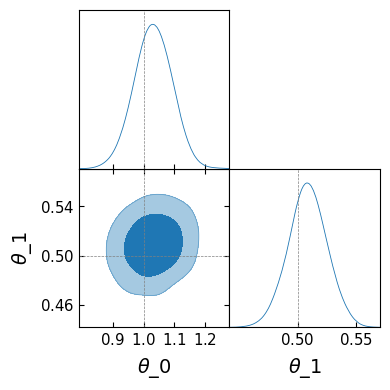

In [8]:
samples = zbi.sample_model(
    run_dir="runs/tutorial_00",
    checkpoint="round_00000_500.pt",
    n_samples=10_000,
)
print(f"Media posterior: theta_0={samples[:,0].mean():.3f}, theta_1={samples[:,1].mean():.3f}")
print(f"Desviacion posterior: theta_0={samples[:,0].std():.3f}, theta_1={samples[:,1].std():.3f}")

zbi.plot(
    all_samples=[samples],
    output="posterior.png",
    run_dir="runs/tutorial_00",
    theta_true=[1.0, 0.5],
    param_names=[r'\theta_0', r'\theta_1'],
)
from IPython.display import display, Image
display(Image(filename="runs/tutorial_00/plots/posterior.png"))